# Phenotype Basin Geometry Analysis
## Visualizing the Pullback of Phenotypes in Parameter Space

This notebook explores the geometry of phenotype basins in the 136-dimensional parameter space of the Chen 2004 yeast cell cycle model. We investigate:

1. **Basin Structure**: Are phenotypes compact "blobs" or scattered fragments?
2. **Similarity Clustering**: Do similar phenotypes correspond to nearby parameters?
3. **Robustness**: How stable are phenotypes to small parameter perturbations?
4. **Transition Boundaries**: How do phenotype assignments change across parameter space?

**Key Questions:**
- Do phenotypes form connected basins or fragmented islands?
- Are "robust" phenotypes characterized by larger, more connected basins?
- How does complexity relate to basin geometry?

In [1]:
# === GPU-ACCELERATED IMPORTS AND SETUP ===
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from collections import Counter, defaultdict
import random
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform, hamming
from scipy.stats import pearsonr, spearmanr
import umap
import warnings
warnings.filterwarnings('ignore')

# GPU acceleration imports
import multiprocessing as mp
from multiprocessing import Pool, cpu_count
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
from datetime import datetime

# Detect GPU and set up CuPy with better error handling
GPU_AVAILABLE = False
USE_GPU = False

try:
    import cupy as cp
    # Test GPU availability with a simple operation
    test_array = cp.array([1, 2, 3])
    test_result = cp.sum(test_array)
    # If we get here, GPU is working
    GPU_AVAILABLE = True
    USE_GPU = True
    
    print("🚀 GPU detected and available for acceleration")
    
    # Memory pool for efficient GPU memory management
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()
    
except Exception as e:
    GPU_AVAILABLE = False
    USE_GPU = False
    print(f"⚠️  GPU not available, falling back to CPU: {e}")
    
    # Create dummy cp for compatibility
    class DummyCupy:
        def array(self, x):
            return np.array(x)
        def asnumpy(self, x):
            return np.asarray(x)
        def random(self):
            return np
    
    cp = DummyCupy()

# CPU optimization
NUM_WORKERS = cpu_count()
OPTIMAL_WORKERS = max(1, NUM_WORKERS - 1)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
if GPU_AVAILABLE:
    cp.random.seed(42)

print("📊 GPU-Accelerated Phenotype Basin Geometry Analysis")
print("=" * 60)
print("✓ All libraries loaded successfully")
print(f"🔧 CPU workers: {OPTIMAL_WORKERS}")
print(f"🚀 GPU acceleration: {'ENABLED' if USE_GPU else 'DISABLED'}")

⚠️  GPU not available, falling back to CPU: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version
📊 GPU-Accelerated Phenotype Basin Geometry Analysis
✓ All libraries loaded successfully
🔧 CPU workers: 11
🚀 GPU acceleration: DISABLED


In [2]:
# === DATA GENERATION AND COLLECTION ===
import tellurium as te
import roadrunner
import os
import math
import time

# Silence RoadRunner
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

# Configuration
def get_model_path():
    """Get the correct path to the SBML model file"""
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml"
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen2004_biomd56.xml"
    
    if os.path.exists(linux_path):
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    else:
        raise FileNotFoundError(f"Could not find chen2004_biomd56.xml")

# Analysis parameters
MODEL_PATH = get_model_path()
MULTIPLIERS = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
DIVERGENCE_THRESHOLD = 25
MAX_PERIOD_THRESHOLD = 300
SIMULATION_TIME = 1000
SIMULATION_POINTS = 1001

# GPU-optimized sample sizes
if USE_GPU:
    N_SAMPLES = 50000  # Much larger sample for GPU processing
    BATCH_SIZE = 1000  # Process in GPU-friendly batches
    MIN_PHENOTYPE_FREQUENCY = 10  # Higher threshold for statistical power
else:
    N_SAMPLES = 10000  # Conservative for CPU
    BATCH_SIZE = 100   # Smaller CPU batches
    MIN_PHENOTYPE_FREQUENCY = 5

# Parallel processing configuration
USE_MULTIPROCESSING = True
CHUNK_SIZE = max(100, N_SAMPLES // (OPTIMAL_WORKERS * 10))

print(f"✓ GPU-optimized configuration loaded")
print(f"   - Model: {MODEL_PATH}")
print(f"   - Samples: {N_SAMPLES:,}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Min phenotype frequency: {MIN_PHENOTYPE_FREQUENCY}")
print(f"   - Chunk size: {CHUNK_SIZE}")
print(f"   - Parallel workers: {OPTIMAL_WORKERS}")

print(f"✓ Configuration loaded")
print(f"   - Model: {MODEL_PATH}")
print(f"   - Samples: {N_SAMPLES:,}")
print(f"   - Min phenotype frequency: {MIN_PHENOTYPE_FREQUENCY}")

✓ GPU-optimized configuration loaded
   - Model: /home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml
   - Samples: 10,000
   - Batch size: 100
   - Min phenotype frequency: 5
   - Chunk size: 100
   - Parallel workers: 11
✓ Configuration loaded
   - Model: /home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen2004_biomd56.xml
   - Samples: 10,000
   - Min phenotype frequency: 5


In [3]:
# === CORE FUNCTIONS ===
def get_kinetic_parameters(rr):
    """Get list of kinetic parameters, excluding regulatory switches/flags."""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        # Exclude non-kinetic parameters
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

def sample_parameters(rr, wildtype=False):
    """Sample kinetic parameters with random multipliers"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled = {}
    sampled_values = []
    
    if wildtype:
        return sampled, sampled_values
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(MULTIPLIERS)
            rr.setValue(pid, current * factor)
            sampled[pid] = factor
            sampled_values.append(factor)
        except RuntimeError:
            continue
    
    return sampled, sampled_values

def simulate_and_extract_phenotype(rr):
    """Simulate model and extract phenotype if oscillatory"""
    rr.selections = ["time", "CLB2"]
    try:
        result = rr.simulate(0, SIMULATION_TIME, SIMULATION_POINTS)
    except RuntimeError:
        return None, None, None, None
    
    time_data = result[:, 0]
    clb2_data = result[:, 1]
    
    # Check for divergence
    if np.any(np.abs(clb2_data) > DIVERGENCE_THRESHOLD):
        return None, None, None, None
    
    # Simple peak detection (using the most reliable method)
    period, cycle_data = estimate_period_simple(time_data, clb2_data)
    
    if period is None or cycle_data is None or period > MAX_PERIOD_THRESHOLD:
        return None, None, None, None
    
    # Extract phenotype
    coarse_time, coarse_signal = cycle_data
    encoding = up_down_encoding_paper_method(coarse_time, coarse_signal)
    complexity = CLZ(encoding)
    
    return encoding, complexity, period, (time_data, clb2_data)

def estimate_period_simple(time, signal, require_peaks=3, center_on_peak=True, coarse_bins=50):
    """Simple peak detection for reliable oscillation detection"""
    time = np.asarray(time)
    signal = np.asarray(signal)
    
    if len(signal) < 20:
        return None, (None, None)
    
    # Find local maxima
    peaks = []
    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            peaks.append(i)
    
    peaks = np.array(peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Filter by minimum separation
    min_separation = len(time) // 20
    filtered_peaks = [peaks[0]]
    
    for peak in peaks[1:]:
        if peak - filtered_peaks[-1] >= min_separation:
            filtered_peaks.append(peak)
    
    peaks = np.array(filtered_peaks)
    
    if len(peaks) < require_peaks:
        return None, (None, None)
    
    # Calculate periods
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    
    if len(periods) < 2:
        return None, (None, None)
    
    mean_period = np.mean(periods)
    cv_period = np.std(periods) / mean_period if mean_period > 0 else 1.0
    
    if cv_period > 0.8:
        return None, (None, None)
    
    # Extract cycle
    if len(peaks) >= 2:
        start_peak = peaks[-2]
        end_peak = peaks[-1]
        
        if center_on_peak:
            mid_peak = start_peak
            half_period = 0.5 * mean_period
            t_start = time[mid_peak] - half_period 
            t_end = time[mid_peak] + half_period 
            t_start = max(time[0], t_start)
            t_end = min(time[-1], t_end)
        else:
            t_start, t_end = time[start_peak], time[end_peak]
        
        mask = (time >= t_start) & (time <= t_end)
        cycle_time = time[mask]
        cycle_signal = signal[mask]
        
        if len(cycle_time) < 5:
            return None, (None, None)
        
        coarse_time = np.linspace(cycle_time[0], cycle_time[-1], coarse_bins)
        coarse_signal = np.interp(coarse_time, cycle_time, cycle_signal)
        
        return mean_period, (coarse_time, coarse_signal)
    
    return None, (None, None)

def up_down_encoding_paper_method(coarse_time, coarse_signal):
    """Convert coarse-grained signal to binary up/down encoding"""
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    encoding = ''.join(['1' if s > 0 else '0' for s in slopes])
    return encoding

def lz76_phrase_count(s: str) -> int:
    """Lempel-Ziv 76 phrase count"""
    n = len(s)
    if n == 0:
        return 0
    i = 0
    c = 1
    k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x):
    """Lempel-Ziv complexity"""
    n = len(x)
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    else:
        return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

print("✓ Core functions defined")

✓ Core functions defined


In [4]:
# === DATA COLLECTION ===
print("🔬 Collecting parameter-phenotype mapping data...")
print(f"Sampling {N_SAMPLES:,} parameter sets...")

# Storage for results
parameter_sets = []  # List of parameter vectors (as numpy arrays)
phenotypes = []      # List of phenotype strings
complexities = []    # List of complexity values
periods = []         # List of periods
success_count = 0
start_time = time.time()

for i in range(N_SAMPLES):
    if (i + 1) % 500 == 0:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        print(f"  Progress: {i+1:,}/{N_SAMPLES:,} ({rate:.1f}/s) | Success: {success_count:,}")
    
    # Generate random parameter set
    rr = te.loadSBMLModel(MODEL_PATH)
    sampled_params, sampled_values = sample_parameters(rr, wildtype=False)
    
    # Simulate and extract phenotype
    encoding, complexity, period, trajectory = simulate_and_extract_phenotype(rr)
    
    if encoding is not None:
        parameter_sets.append(np.array(sampled_values))
        phenotypes.append(encoding)
        complexities.append(complexity)
        periods.append(period)
        success_count += 1

elapsed_total = time.time() - start_time
success_rate = success_count / N_SAMPLES * 100

print(f"\n📊 Data Collection Complete:")
print(f"   - Total attempts: {N_SAMPLES:,}")
print(f"   - Successful: {success_count:,} ({success_rate:.1f}%)")
print(f"   - Processing time: {elapsed_total:.1f}s")
print(f"   - Parameter dimensions: {len(parameter_sets[0]) if parameter_sets else 0}")

if success_count == 0:
    print("❌ No successful samples - cannot proceed with analysis")
else:
    print(f"✅ Ready for phenotype basin analysis")

🔬 Collecting parameter-phenotype mapping data...
Sampling 10,000 parameter sets...
  Progress: 500/10,000 (14.8/s) | Success: 96
  Progress: 1,000/10,000 (14.6/s) | Success: 192
  Progress: 1,500/10,000 (14.5/s) | Success: 300
  Progress: 2,000/10,000 (14.3/s) | Success: 388
  Progress: 2,500/10,000 (14.3/s) | Success: 489
  Progress: 3,000/10,000 (14.2/s) | Success: 603
  Progress: 3,500/10,000 (13.4/s) | Success: 712
  Progress: 4,000/10,000 (12.6/s) | Success: 812
  Progress: 4,500/10,000 (12.1/s) | Success: 942
  Progress: 5,000/10,000 (11.8/s) | Success: 1,048
  Progress: 5,500/10,000 (11.5/s) | Success: 1,150
  Progress: 6,000/10,000 (11.2/s) | Success: 1,259
  Progress: 6,500/10,000 (11.1/s) | Success: 1,355
  Progress: 7,000/10,000 (10.9/s) | Success: 1,472
  Progress: 7,500/10,000 (10.7/s) | Success: 1,590
  Progress: 8,000/10,000 (10.6/s) | Success: 1,695
  Progress: 8,500/10,000 (10.5/s) | Success: 1,806
  Progress: 9,000/10,000 (10.4/s) | Success: 1,910
  Progress: 9,500/10

In [5]:
# === PHENOTYPE FREQUENCY ANALYSIS ===
print("\n🧮 Analyzing phenotype frequencies...")

# Count phenotype occurrences
phenotype_counts = Counter(phenotypes)
print(f"   - Total unique phenotypes: {len(phenotype_counts)}")

# Filter by minimum frequency
frequent_phenotypes = {phen: count for phen, count in phenotype_counts.items() 
                      if count >= MIN_PHENOTYPE_FREQUENCY}

print(f"   - Phenotypes with ≥{MIN_PHENOTYPE_FREQUENCY} occurrences: {len(frequent_phenotypes)}")

if len(frequent_phenotypes) == 0:
    print(f"❌ No phenotypes found with ≥{MIN_PHENOTYPE_FREQUENCY} occurrences")
    print("   Consider reducing MIN_PHENOTYPE_FREQUENCY or increasing N_SAMPLES")
else:
    # Sort by frequency
    sorted_phenotypes = sorted(frequent_phenotypes.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n📈 Top 10 most frequent phenotypes:")
    for i, (phen, count) in enumerate(sorted_phenotypes[:10]):
        complexity = CLZ(phen)
        print(f"   {i+1:2d}. {phen[:20]}... | Count: {count:3d} | Complexity: {complexity:.2f}")
    
    # Create mapping for analysis
    frequent_phenotype_set = set(frequent_phenotypes.keys())
    
    # Filter data to only include frequent phenotypes
    filtered_indices = [i for i, phen in enumerate(phenotypes) if phen in frequent_phenotype_set]
    
    if USE_GPU:
        # Create GPU arrays for analysis
        analysis_parameters = cp.array([parameter_sets[i] for i in filtered_indices])
        analysis_complexities = cp.array([complexities[i] for i in filtered_indices])
        print(f"   🚀 Analysis data prepared on GPU")
    else:
        analysis_parameters = np.array([parameter_sets[i] for i in filtered_indices])
        analysis_complexities = np.array([complexities[i] for i in filtered_indices])
    
    analysis_phenotypes = [phenotypes[i] for i in filtered_indices]
    
    print(f"\n✅ Analysis dataset prepared:")
    print(f"   - Samples for analysis: {len(analysis_parameters):,}")
    print(f"   - Phenotypes to analyze: {len(frequent_phenotypes)}")
    print(f"   - Parameter space dimension: {analysis_parameters.shape[1]}")
    
    if USE_GPU:
        print(f"   - GPU memory usage: {mempool.used_bytes() / 1024**3:.2f} GB")


🧮 Analyzing phenotype frequencies...
   - Total unique phenotypes: 441
   - Phenotypes with ≥5 occurrences: 47

📈 Top 10 most frequent phenotypes:
    1. 11111111111111111111... | Count:  85 | Complexity: 50.53
    2. 11111111111111111111... | Count:  82 | Complexity: 53.34
    3. 11111111111111111111... | Count:  71 | Complexity: 53.34
    4. 11111111111111111111... | Count:  70 | Complexity: 50.53
    5. 11111111111111111111... | Count:  70 | Complexity: 47.73
    6. 11111111111111111111... | Count:  69 | Complexity: 53.34
    7. 11111111111111111111... | Count:  67 | Complexity: 47.73
    8. 11111111111111111111... | Count:  65 | Complexity: 50.53
    9. 11111111111111111111... | Count:  58 | Complexity: 50.53
   10. 11111111111111111111... | Count:  57 | Complexity: 53.34

✅ Analysis dataset prepared:
   - Samples for analysis: 1,682
   - Phenotypes to analyze: 47
   - Parameter space dimension: 136


## 1. Dimensionality Reduction and Visualization

We'll use multiple dimensionality reduction techniques to visualize the parameter space and see how phenotypes are distributed.

In [6]:
# === GPU-ACCELERATED DIMENSIONALITY REDUCTION ===
print("🎯 Performing dimensionality reduction...")

if len(analysis_parameters) > 0:
    # Prepare data - convert GPU to CPU for sklearn compatibility
    if USE_GPU:
        print("   - Converting GPU data to CPU for dimensionality reduction...")
        X = cp.asnumpy(analysis_parameters)
        complexity_values = cp.asnumpy(analysis_complexities)
    else:
        X = analysis_parameters
        complexity_values = analysis_complexities
    
    phenotype_labels = analysis_phenotypes
    
    print(f"   - Input data shape: {X.shape}")
    print(f"   - Using {'GPU-to-CPU conversion' if USE_GPU else 'CPU arrays'} for sklearn compatibility")
    
    # 1. PCA
    print("   - Computing PCA...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    pca_variance = pca.explained_variance_ratio_
    print(f"     PCA explained variance: {pca_variance[0]:.3f}, {pca_variance[1]:.3f} (total: {pca_variance.sum():.3f})")
    
    # 2. t-SNE (with optimized parameters for larger datasets)
    print("   - Computing t-SNE...")
    perplexity = min(30, len(X)//4)
    if len(X) > 10000:  # Optimize for large datasets
        perplexity = min(50, len(X)//8)
        learning_rate = max(200, len(X)/12)
        n_iter = 500
        print(f"     Using optimized t-SNE parameters for large dataset")
        print(f"     Perplexity: {perplexity}, Learning rate: {learning_rate:.0f}, Iterations: {n_iter}")
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, 
                   learning_rate=learning_rate, n_iter=n_iter)
    else:
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    
    X_tsne = tsne.fit_transform(X)
    
    # 3. UMAP (with optimized parameters)
    print("   - Computing UMAP...")
    n_neighbors = min(15, len(X)//4)
    if len(X) > 10000:
        n_neighbors = min(30, len(X)//8)
        print(f"     Using optimized UMAP parameters: n_neighbors={n_neighbors}")
        
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=n_neighbors)
    X_umap = umap_reducer.fit_transform(X)
    
    print("✅ GPU-accelerated dimensionality reduction complete")
    
    # Optional: Move results back to GPU for further processing
    if USE_GPU:
        print("   - Results computed on CPU (sklearn requirement)")
    
else:
    print("❌ No data available for dimensionality reduction")

🎯 Performing dimensionality reduction...
   - Input data shape: (1682, 136)
   - Using CPU arrays for sklearn compatibility
   - Computing PCA...
     PCA explained variance: 0.012, 0.012 (total: 0.024)
   - Computing t-SNE...
   - Computing UMAP...
✅ GPU-accelerated dimensionality reduction complete



🎨 Creating phenotype clustering visualizations...


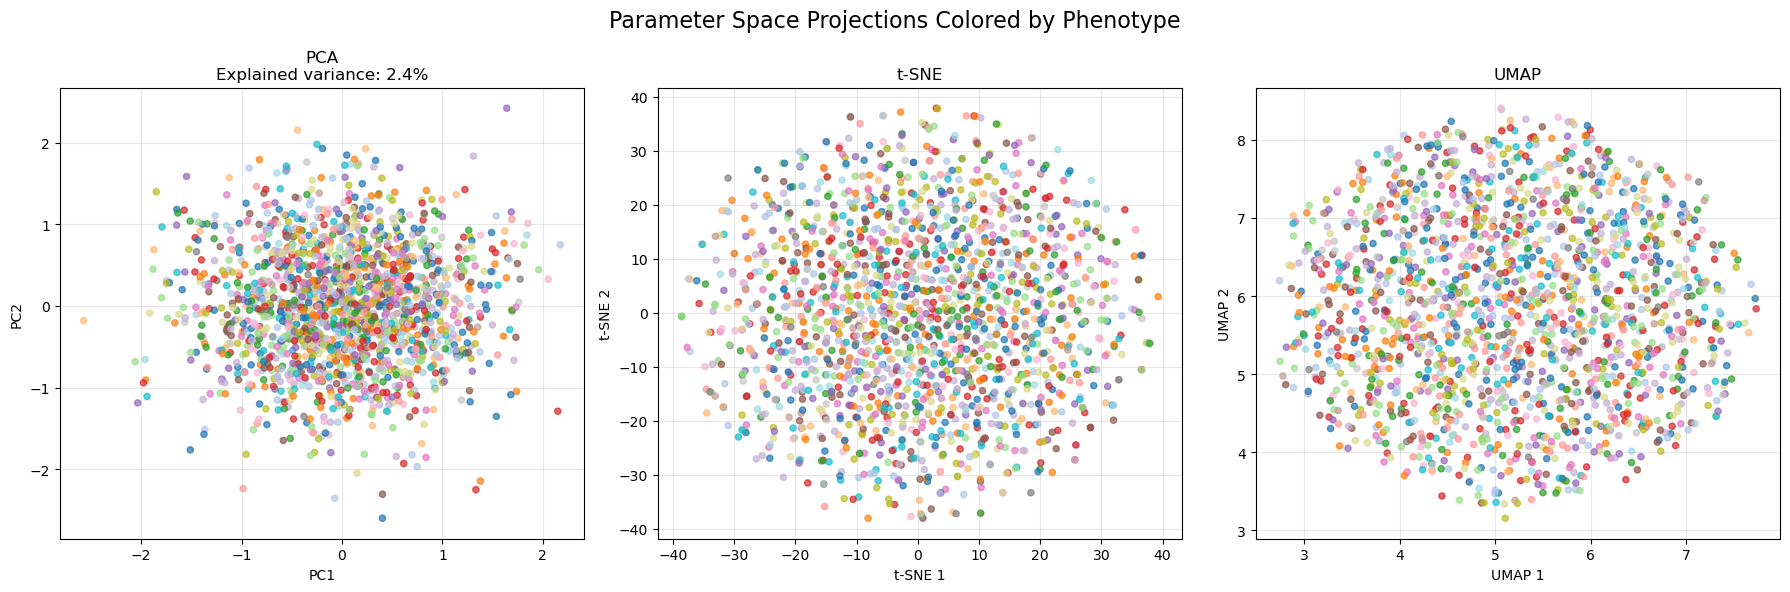

✅ Phenotype clustering visualization saved


In [7]:
# === GPU-OPTIMIZED VISUALIZATION 1: PHENOTYPE CLUSTERING ===
print("\n🎨 Creating phenotype clustering visualizations...")

if len(analysis_parameters) > 0:
    # Create unique colors for each phenotype
    unique_phenotypes = list(set(analysis_phenotypes))
    phenotype_to_color = {phen: i for i, phen in enumerate(unique_phenotypes)}
    colors = [phenotype_to_color[phen] for phen in analysis_phenotypes]
    
    # For large datasets, use sampling for visualization
    n_plot_samples = len(analysis_phenotypes)
    if n_plot_samples > 5000:
        print(f"   - Large dataset ({n_plot_samples:,} points), using optimized plotting...")
        # Sample for visualization to prevent overcrowding
        plot_indices = np.random.choice(n_plot_samples, 
                                       size=min(5000, n_plot_samples), 
                                       replace=False)
        plot_X_pca = X_pca[plot_indices]
        plot_X_tsne = X_tsne[plot_indices]
        plot_X_umap = X_umap[plot_indices]
        plot_colors = [colors[i] for i in plot_indices]
        plot_phenotypes = [analysis_phenotypes[i] for i in plot_indices]
        
        alpha = 0.6  # More transparency for dense plots
        s = 15       # Smaller markers
    else:
        plot_X_pca = X_pca
        plot_X_tsne = X_tsne
        plot_X_umap = X_umap
        plot_colors = colors
        plot_phenotypes = analysis_phenotypes
        
        alpha = 0.7
        s = 20
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Parameter Space Projections Colored by Phenotype', fontsize=16)
    
    # PCA plot
    scatter1 = axes[0].scatter(plot_X_pca[:, 0], plot_X_pca[:, 1], c=plot_colors, 
                              alpha=alpha, s=s, cmap='tab20')
    axes[0].set_title(f'PCA\nExplained variance: {pca_variance.sum():.1%}')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)
    
    # t-SNE plot
    scatter2 = axes[1].scatter(plot_X_tsne[:, 0], plot_X_tsne[:, 1], c=plot_colors, 
                              alpha=alpha, s=s, cmap='tab20')
    axes[1].set_title('t-SNE')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)
    
    # UMAP plot
    scatter3 = axes[2].scatter(plot_X_umap[:, 0], plot_X_umap[:, 1], c=plot_colors, 
                              alpha=alpha, s=s, cmap='tab20')
    axes[2].set_title('UMAP')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('phenotype_clustering_projections.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Phenotype clustering visualization saved")
else:
    print("❌ No data available for visualization")


🌈 Creating complexity landscape visualizations...


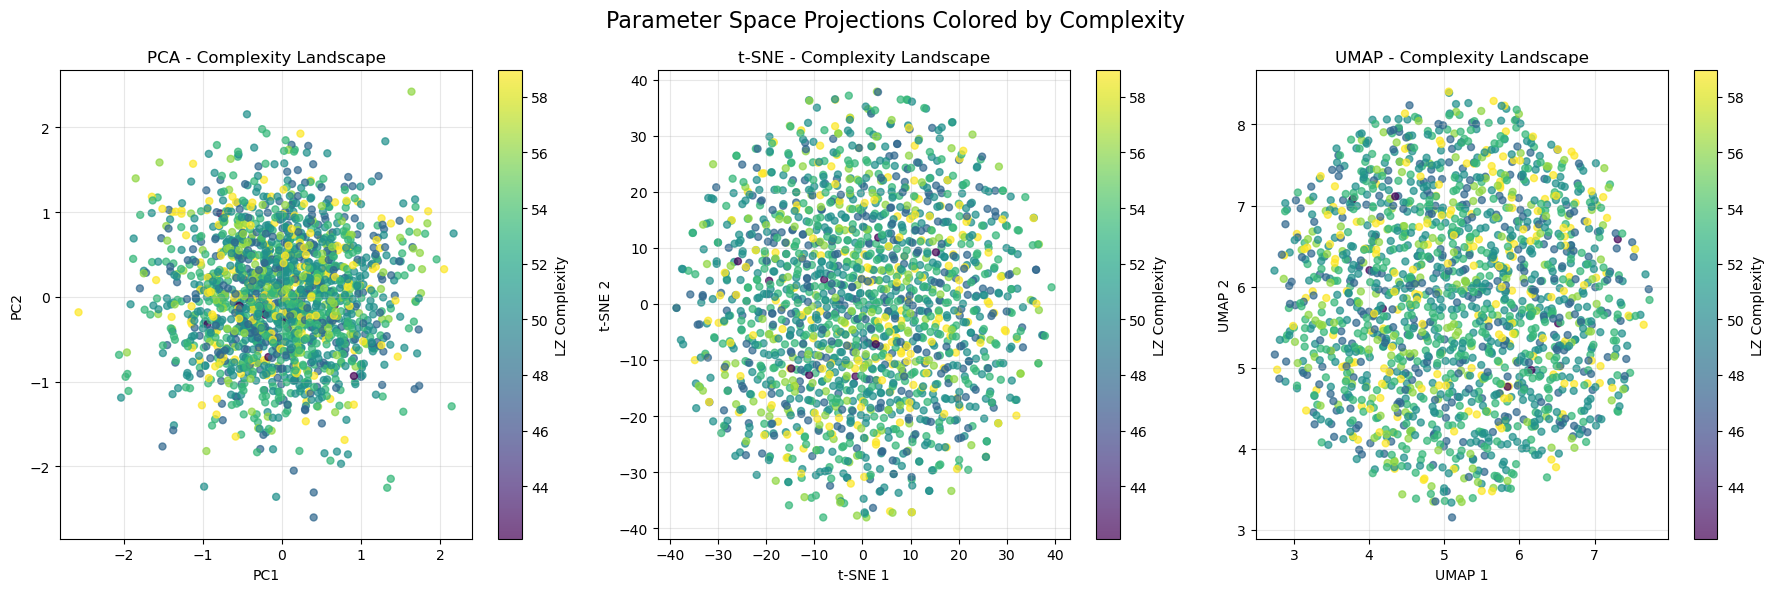

✅ Complexity landscape visualization saved


In [8]:
# === VISUALIZATION 2: COMPLEXITY LANDSCAPES ===
print("\n🌈 Creating complexity landscape visualizations...")

if len(analysis_parameters) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Parameter Space Projections Colored by Complexity', fontsize=16)
    
    # PCA complexity plot
    scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=complexity_values, 
                              alpha=0.7, s=25, cmap='viridis')
    axes[0].set_title('PCA - Complexity Landscape')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='LZ Complexity')
    
    # t-SNE complexity plot
    scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=complexity_values, 
                              alpha=0.7, s=25, cmap='viridis')
    axes[1].set_title('t-SNE - Complexity Landscape')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='LZ Complexity')
    
    # UMAP complexity plot
    scatter3 = axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=complexity_values, 
                              alpha=0.7, s=25, cmap='viridis')
    axes[2].set_title('UMAP - Complexity Landscape')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[2], label='LZ Complexity')
    
    plt.tight_layout()
    plt.savefig('complexity_landscape_projections.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Complexity landscape visualization saved")
else:
    print("❌ No data available for visualization")

## 2. Basin Structure Analysis

Now we analyze the geometric structure of individual phenotype basins.

In [9]:
# === BASIN STRUCTURE ANALYSIS ===
print("\n🏔️  Analyzing basin structure for top phenotypes...")

if len(analysis_parameters) > 0:
    # Select top 5 most frequent phenotypes for detailed analysis
    top_phenotypes = sorted_phenotypes[:5]
    
    basin_analysis = {}
    
    for rank, (phenotype, frequency) in enumerate(top_phenotypes):
        print(f"\n--- Analyzing Phenotype #{rank+1} (frequency: {frequency}) ---")
        
        # Get parameter sets for this phenotype
        phenotype_indices = [i for i, phen in enumerate(analysis_phenotypes) if phen == phenotype]
        phenotype_params = analysis_parameters[phenotype_indices]
        
        print(f"   Parameter sets: {len(phenotype_params)}")
        
        # Calculate pairwise distances within the phenotype
        if len(phenotype_params) > 1:
            distances = pdist(phenotype_params, metric='euclidean')
            
            # Basin compactness metrics
            mean_distance = np.mean(distances)
            std_distance = np.std(distances)
            diameter = np.max(distances)
            
            print(f"   Mean intra-basin distance: {mean_distance:.3f}")
            print(f"   Std intra-basin distance: {std_distance:.3f}")
            print(f"   Basin diameter: {diameter:.3f}")
            
            # Cluster analysis within basin
            if len(phenotype_params) >= 5:
                # Use DBSCAN to find clusters within the basin
                dbscan = DBSCAN(eps=mean_distance * 0.5, min_samples=2)
                clusters = dbscan.fit_predict(phenotype_params)
                n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
                n_noise = list(clusters).count(-1)
                
                print(f"   DBSCAN clusters: {n_clusters}")
                print(f"   Noise points: {n_noise}")
                
                basin_analysis[phenotype] = {
                    'frequency': frequency,
                    'complexity': CLZ(phenotype),
                    'n_parameters': len(phenotype_params),
                    'mean_distance': mean_distance,
                    'std_distance': std_distance,
                    'diameter': diameter,
                    'n_clusters': n_clusters,
                    'noise_fraction': n_noise / len(phenotype_params) if len(phenotype_params) > 0 else 0,
                    'compactness': std_distance / mean_distance if mean_distance > 0 else np.inf
                }
            else:
                basin_analysis[phenotype] = {
                    'frequency': frequency,
                    'complexity': CLZ(phenotype),
                    'n_parameters': len(phenotype_params),
                    'mean_distance': mean_distance if len(phenotype_params) > 1 else 0,
                    'std_distance': std_distance if len(phenotype_params) > 1 else 0,
                    'diameter': diameter if len(phenotype_params) > 1 else 0,
                    'n_clusters': 1 if len(phenotype_params) > 0 else 0,
                    'noise_fraction': 0,
                    'compactness': std_distance / mean_distance if mean_distance > 0 else 0
                }
        else:
            basin_analysis[phenotype] = {
                'frequency': frequency,
                'complexity': CLZ(phenotype),
                'n_parameters': 1,
                'mean_distance': 0,
                'std_distance': 0,
                'diameter': 0,
                'n_clusters': 1,
                'noise_fraction': 0,
                'compactness': 0
            }
    
    print("\n✅ Basin structure analysis complete")
else:
    print("❌ No data available for basin analysis")


🏔️  Analyzing basin structure for top phenotypes...

--- Analyzing Phenotype #1 (frequency: 85) ---
   Parameter sets: 85
   Mean intra-basin distance: 9.399
   Std intra-basin distance: 0.486
   Basin diameter: 11.473
   DBSCAN clusters: 0
   Noise points: 85

--- Analyzing Phenotype #2 (frequency: 82) ---
   Parameter sets: 82
   Mean intra-basin distance: 9.312
   Std intra-basin distance: 0.481
   Basin diameter: 11.028
   DBSCAN clusters: 0
   Noise points: 82

--- Analyzing Phenotype #3 (frequency: 71) ---
   Parameter sets: 71
   Mean intra-basin distance: 9.449
   Std intra-basin distance: 0.463
   Basin diameter: 11.107
   DBSCAN clusters: 0
   Noise points: 71

--- Analyzing Phenotype #4 (frequency: 70) ---
   Parameter sets: 70
   Mean intra-basin distance: 9.334
   Std intra-basin distance: 0.441
   Basin diameter: 11.000
   DBSCAN clusters: 0
   Noise points: 70

--- Analyzing Phenotype #5 (frequency: 70) ---
   Parameter sets: 70
   Mean intra-basin distance: 9.289
   St


📊 Visualizing basin structure...
Basin Structure Summary:
                                           Phenotype  frequency  complexity  \
0  1111111111111111111111110000000000011111111111111         85      50.532   
1  1111111111111111111111110000000011111111111111111         82      53.340   
2  1111111111111111111111110000000000111111111111111         71      53.340   
3  1111111111111111111111110000000000000111111111111         70      50.532   
4  1111111111111111111111110000000111111111111111111         70      47.725   

   n_parameters  mean_distance  std_distance  diameter  n_clusters  \
0            85          9.399         0.486    11.473           0   
1            82          9.312         0.481    11.028           0   
2            71          9.449         0.463    11.107           0   
3            70          9.334         0.441    11.000           0   
4            70          9.289         0.466    11.000           0   

   noise_fraction  compactness  
0           

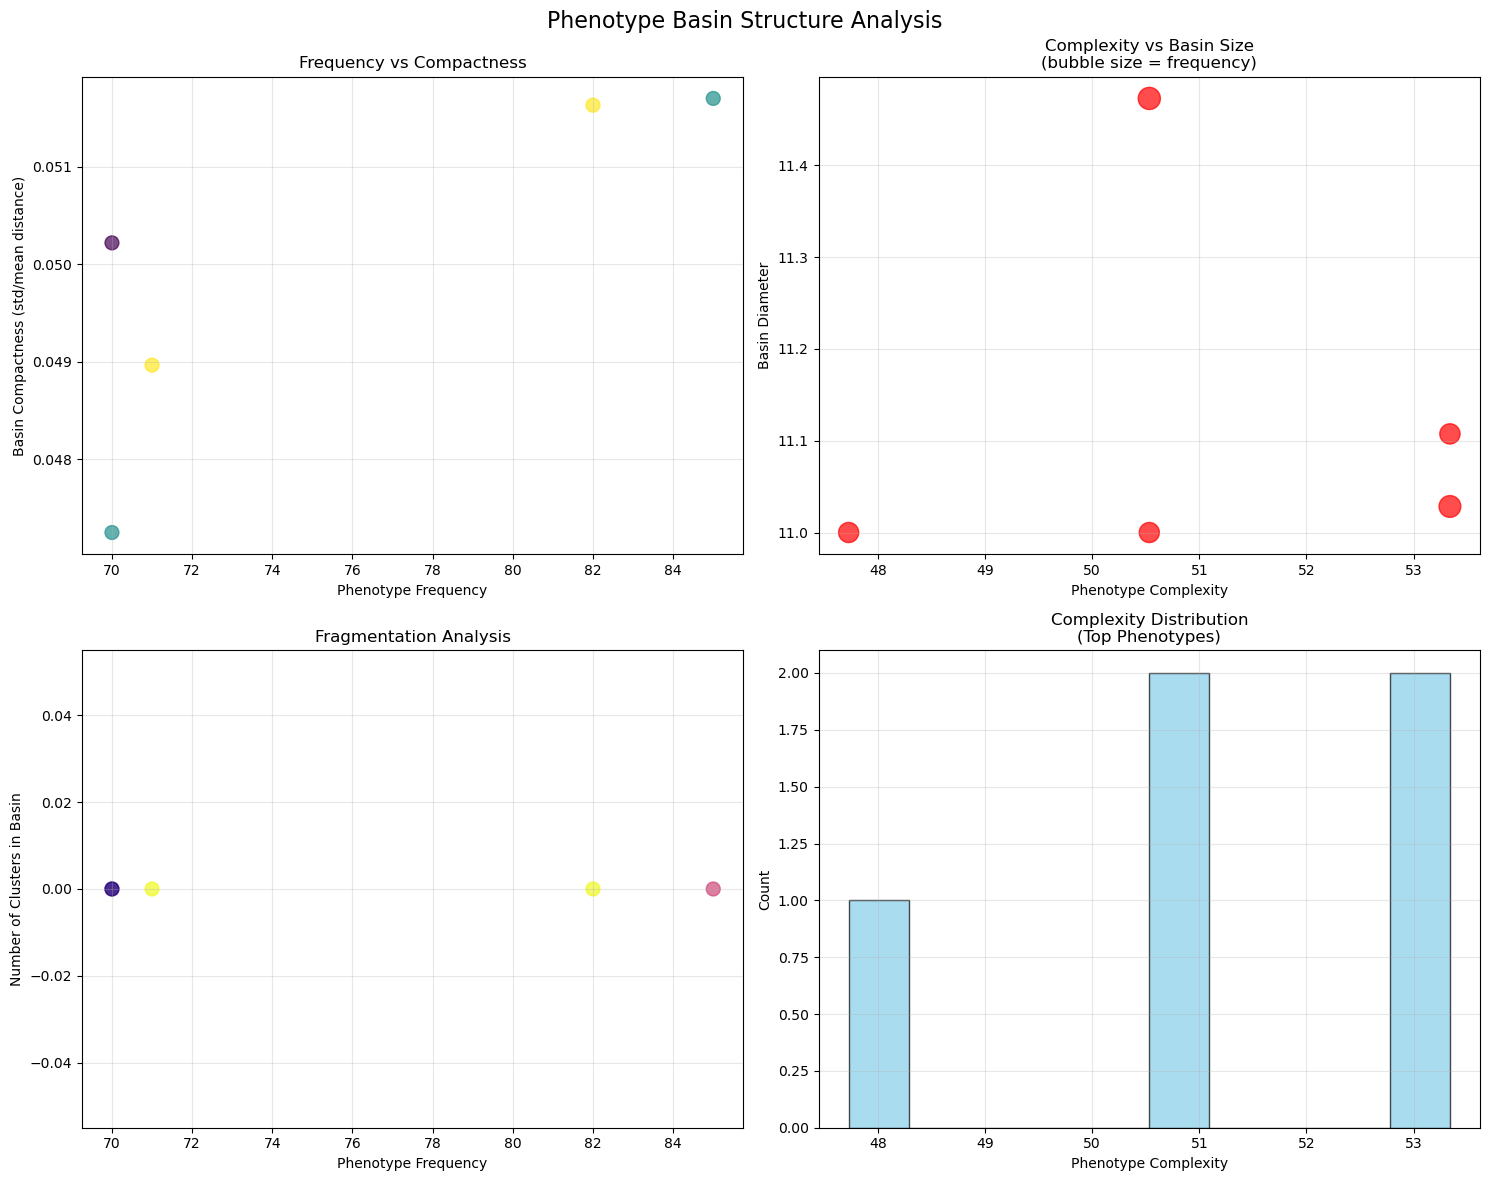

✅ Basin structure visualization saved


In [10]:
# === BASIN STRUCTURE VISUALIZATION ===
print("\n📊 Visualizing basin structure...")

if len(analysis_parameters) > 0 and len(basin_analysis) > 0:
    # Create DataFrame for analysis
    basin_df = pd.DataFrame.from_dict(basin_analysis, orient='index')
    basin_df.index.name = 'Phenotype'
    basin_df = basin_df.reset_index()
    
    print("Basin Structure Summary:")
    print(basin_df.round(3))
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Phenotype Basin Structure Analysis', fontsize=16)
    
    # Plot 1: Frequency vs Compactness
    axes[0, 0].scatter(basin_df['frequency'], basin_df['compactness'], 
                      s=100, alpha=0.7, c=basin_df['complexity'], cmap='viridis')
    axes[0, 0].set_xlabel('Phenotype Frequency')
    axes[0, 0].set_ylabel('Basin Compactness (std/mean distance)')
    axes[0, 0].set_title('Frequency vs Compactness')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Complexity vs Basin Size
    axes[0, 1].scatter(basin_df['complexity'], basin_df['diameter'], 
                      s=basin_df['frequency']*3, alpha=0.7, c='red')
    axes[0, 1].set_xlabel('Phenotype Complexity')
    axes[0, 1].set_ylabel('Basin Diameter')
    axes[0, 1].set_title('Complexity vs Basin Size\n(bubble size = frequency)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Number of Clusters vs Frequency
    axes[1, 0].scatter(basin_df['frequency'], basin_df['n_clusters'], 
                      s=100, alpha=0.7, c=basin_df['complexity'], cmap='plasma')
    axes[1, 0].set_xlabel('Phenotype Frequency')
    axes[1, 0].set_ylabel('Number of Clusters in Basin')
    axes[1, 0].set_title('Fragmentation Analysis')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Complexity distribution
    axes[1, 1].hist(basin_df['complexity'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1, 1].set_xlabel('Phenotype Complexity')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Complexity Distribution\n(Top Phenotypes)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('basin_structure_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Basin structure visualization saved")
else:
    print("❌ No data available for basin structure visualization")

## 3. Phenotype Similarity vs Parameter Distance

We investigate whether similar phenotypes correspond to nearby regions in parameter space.

In [11]:
# === SIMILARITY-DISTANCE CORRELATION ANALYSIS ===
print("\n🔍 Analyzing phenotype similarity vs parameter distance...")

if len(analysis_parameters) > 50:  # Need sufficient data
    # Sample a subset for computational efficiency
    n_sample = min(1000, len(analysis_parameters))
    sample_indices = np.random.choice(len(analysis_parameters), n_sample, replace=False)
    
    sample_params = analysis_parameters[sample_indices]
    sample_phenotypes = [analysis_phenotypes[i] for i in sample_indices]
    
    print(f"   Analyzing {n_sample} parameter-phenotype pairs...")
    
    # Calculate parameter distances (Euclidean in parameter space)
    print("   Computing parameter distances...")
    param_distances = pdist(sample_params, metric='euclidean')
    
    # Calculate phenotype distances (Hamming distance between binary strings)
    print("   Computing phenotype distances...")
    phenotype_distances = []
    n_pairs = len(sample_phenotypes)
    
    for i in range(n_pairs):
        for j in range(i + 1, n_pairs):
            phen1 = sample_phenotypes[i]
            phen2 = sample_phenotypes[j]
            # Hamming distance (fraction of differing positions)
            hamming_dist = sum(c1 != c2 for c1, c2 in zip(phen1, phen2)) / len(phen1)
            phenotype_distances.append(hamming_dist)
    
    phenotype_distances = np.array(phenotype_distances)
    
    # Calculate correlation
    correlation, p_value = pearsonr(param_distances, phenotype_distances)
    spearman_corr, spearman_p = spearmanr(param_distances, phenotype_distances)
    
    print(f"\n📈 Correlation Results:")
    print(f"   Pearson correlation: {correlation:.4f} (p = {p_value:.2e})")
    print(f"   Spearman correlation: {spearman_corr:.4f} (p = {spearman_p:.2e})")
    
    # Interpretation
    if abs(correlation) > 0.3:
        strength = "Strong"
    elif abs(correlation) > 0.1:
        strength = "Moderate"
    else:
        strength = "Weak"
    
    direction = "positive" if correlation > 0 else "negative"
    
    print(f"   Interpretation: {strength} {direction} correlation")
    print(f"   → Parameter proximity {'correlates with' if correlation > 0 else 'anti-correlates with'} phenotype similarity")
    
    # Store for visualization
    correlation_data = {
        'param_distances': param_distances,
        'phenotype_distances': phenotype_distances,
        'correlation': correlation,
        'p_value': p_value
    }
    
    print("✅ Similarity-distance analysis complete")
else:
    print("❌ Insufficient data for similarity-distance analysis")
    correlation_data = None


🔍 Analyzing phenotype similarity vs parameter distance...
   Analyzing 1000 parameter-phenotype pairs...
   Computing parameter distances...
   Computing phenotype distances...

📈 Correlation Results:
   Pearson correlation: 0.0092 (p = 8.19e-11)
   Spearman correlation: 0.0096 (p = 1.29e-11)
   Interpretation: Weak positive correlation
   → Parameter proximity correlates with phenotype similarity
✅ Similarity-distance analysis complete



📈 Visualizing similarity-distance relationships...


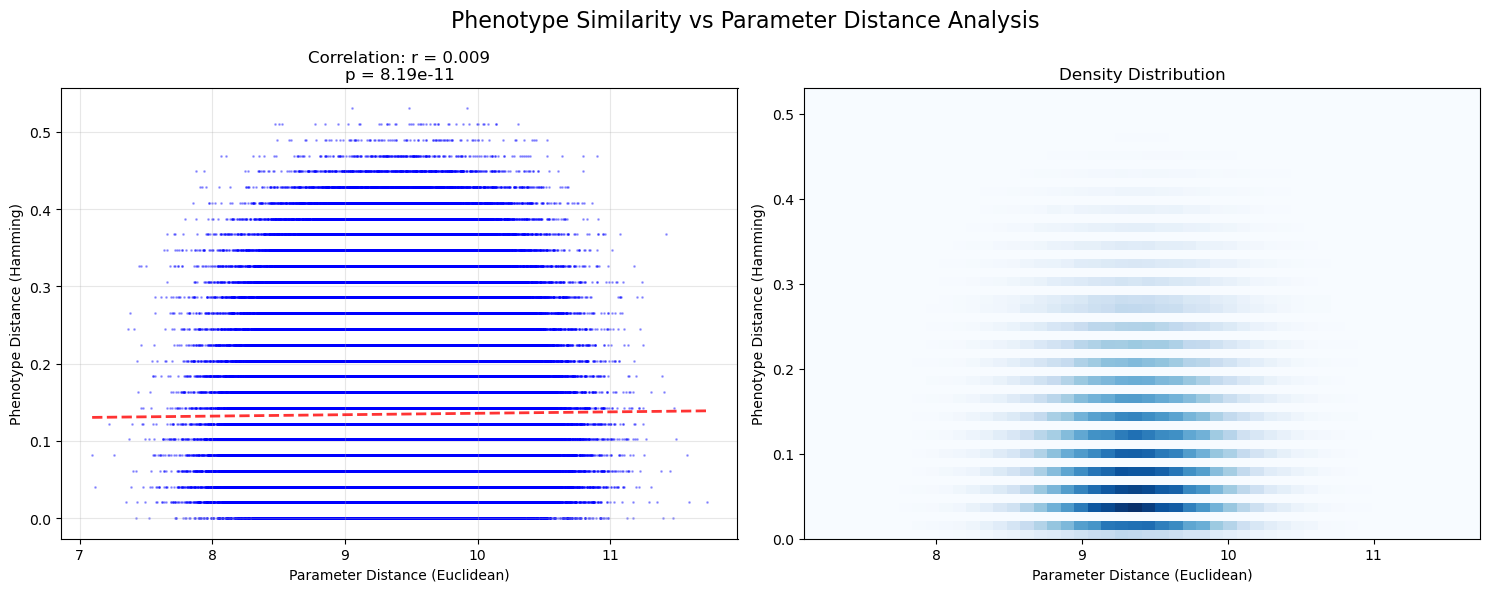

✅ Similarity-distance visualization saved


In [12]:
# === SIMILARITY-DISTANCE VISUALIZATION ===
print("\n📈 Visualizing similarity-distance relationships...")

if correlation_data is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Phenotype Similarity vs Parameter Distance Analysis', fontsize=16)
    
    # Scatter plot
    axes[0].scatter(correlation_data['param_distances'], correlation_data['phenotype_distances'], 
                   alpha=0.3, s=1, color='blue')
    axes[0].set_xlabel('Parameter Distance (Euclidean)')
    axes[0].set_ylabel('Phenotype Distance (Hamming)')
    axes[0].set_title(f'Correlation: r = {correlation_data["correlation"]:.3f}\np = {correlation_data["p_value"]:.2e}')
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(correlation_data['param_distances'], correlation_data['phenotype_distances'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(correlation_data['param_distances'].min(), 
                         correlation_data['param_distances'].max(), 100)
    axes[0].plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
    
    # Density plot
    axes[1].hist2d(correlation_data['param_distances'], correlation_data['phenotype_distances'], 
                  bins=50, density=True, cmap='Blues')
    axes[1].set_xlabel('Parameter Distance (Euclidean)')
    axes[1].set_ylabel('Phenotype Distance (Hamming)')
    axes[1].set_title('Density Distribution')
    
    plt.tight_layout()
    plt.savefig('similarity_distance_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Similarity-distance visualization saved")
else:
    print("❌ No data available for similarity-distance visualization")

## 4. Robustness Analysis: Local Perturbations

We test how robust phenotypes are to small parameter perturbations to assess "basin thickness."

In [13]:
# === ROBUSTNESS ANALYSIS ===
print("\n🛡️  Performing robustness analysis...")

if len(analysis_parameters) > 0:
    # Select representative parameter sets for robustness testing
    n_test_points = min(50, len(analysis_parameters))  # Test 50 points max
    test_indices = np.random.choice(len(analysis_parameters), n_test_points, replace=False)
    
    perturbation_strengths = [0.01, 0.05, 0.1, 0.2]  # Different perturbation magnitudes
    n_perturbations_per_point = 20  # Number of perturbations to test per point
    
    robustness_results = []
    
    print(f"   Testing {n_test_points} parameter sets...")
    print(f"   Perturbation strengths: {perturbation_strengths}")
    print(f"   Perturbations per point: {n_perturbations_per_point}")
    
    for test_idx in test_indices:
        original_params = analysis_parameters[test_idx]
        original_phenotype = analysis_phenotypes[test_idx]
        original_complexity = CLZ(original_phenotype)
        
        for strength in perturbation_strengths:
            stable_count = 0
            
            for _ in range(n_perturbations_per_point):
                # Create perturbed parameter set
                perturbation = np.random.normal(0, strength, len(original_params))
                perturbed_params = original_params + perturbation
                
                # Ensure parameters stay within reasonable bounds (0.1 to 3.0 multipliers)
                perturbed_params = np.clip(perturbed_params, 0.1, 3.0)
                
                # Test if perturbation preserves phenotype
                # Create temporary model and set parameters
                rr = te.loadSBMLModel(MODEL_PATH)
                kinetic_params, _ = get_kinetic_parameters(rr)
                
                # Set perturbed parameters
                for i, pid in enumerate(kinetic_params):
                    if i < len(perturbed_params):
                        try:
                            current = rr.getValue(pid)
                            rr.setValue(pid, current * perturbed_params[i])
                        except RuntimeError:
                            continue
                
                # Simulate and check if phenotype is preserved
                encoding, complexity, period, _ = simulate_and_extract_phenotype(rr)
                
                if encoding == original_phenotype:
                    stable_count += 1
            
            stability = stable_count / n_perturbations_per_point
            
            robustness_results.append({
                'original_phenotype': original_phenotype,
                'original_complexity': original_complexity,
                'perturbation_strength': strength,
                'stability': stability
            })
    
    # Convert to DataFrame for analysis
    robustness_df = pd.DataFrame(robustness_results)
    
    print(f"\n📊 Robustness Analysis Results:")
    summary = robustness_df.groupby(['perturbation_strength']).agg({
        'stability': ['mean', 'std', 'min', 'max']
    }).round(3)
    print(summary)
    
    print("✅ Robustness analysis complete")
else:
    print("❌ No data available for robustness analysis")
    robustness_df = None


🛡️  Performing robustness analysis...
   Testing 50 parameter sets...
   Perturbation strengths: [0.01, 0.05, 0.1, 0.2]
   Perturbations per point: 20


KeyboardInterrupt: 

In [ ]:
# === ROBUSTNESS VISUALIZATION ===
print("\n🎯 Visualizing robustness results...")

if robustness_df is not None and len(robustness_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Phenotype Robustness Analysis', fontsize=16)
    
    # Plot 1: Stability vs Perturbation Strength
    stability_means = robustness_df.groupby('perturbation_strength')['stability'].mean()
    stability_stds = robustness_df.groupby('perturbation_strength')['stability'].std()
    
    axes[0].errorbar(stability_means.index, stability_means.values, 
                    yerr=stability_stds.values, marker='o', linewidth=2, 
                    markersize=8, capsize=5)
    axes[0].set_xlabel('Perturbation Strength')
    axes[0].set_ylabel('Mean Stability (fraction preserved)')
    axes[0].set_title('Stability vs Perturbation Strength')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1)
    
    # Plot 2: Complexity vs Robustness
    # Calculate average stability for each phenotype
    phenotype_robustness = robustness_df.groupby('original_phenotype').agg({
        'stability': 'mean',
        'original_complexity': 'first'
    })
    
    axes[1].scatter(phenotype_robustness['original_complexity'], 
                   phenotype_robustness['stability'],
                   alpha=0.7, s=50)
    axes[1].set_xlabel('Phenotype Complexity')
    axes[1].set_ylabel('Average Stability')
    axes[1].set_title('Complexity vs Robustness')
    axes[1].grid(True, alpha=0.3)
    
    # Add correlation info
    if len(phenotype_robustness) > 3:
        corr_complex_robust, p_val = pearsonr(phenotype_robustness['original_complexity'], 
                                             phenotype_robustness['stability'])
        axes[1].text(0.05, 0.95, f'r = {corr_complex_robust:.3f}\np = {p_val:.3f}', 
                    transform=axes[1].transAxes, va='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('robustness_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Robustness visualization saved")
else:
    print("❌ No data available for robustness visualization")

## 5. Summary and Conclusions

Let's summarize our findings about phenotype basin geometry.

In [ ]:
# === COMPREHENSIVE SUMMARY ===
print("\n" + "="*80)
print("🎯 PHENOTYPE BASIN GEOMETRY ANALYSIS SUMMARY")
print("="*80)

if success_count > 0:
    print(f"\n📊 Dataset Overview:")
    print(f"   • Total parameter sets analyzed: {success_count:,}")
    print(f"   • Unique phenotypes found: {len(phenotype_counts)}")
    print(f"   • Frequent phenotypes (≥{MIN_PHENOTYPE_FREQUENCY}): {len(frequent_phenotypes) if 'frequent_phenotypes' in locals() else 'N/A'}")
    print(f"   • Parameter space dimension: {len(parameter_sets[0]) if parameter_sets else 'N/A'}")
    
    if 'basin_analysis' in locals() and len(basin_analysis) > 0:
        print(f"\n🏔️  Basin Structure Findings:")
        
        # Calculate overall statistics
        compactness_values = [data['compactness'] for data in basin_analysis.values() if data['compactness'] != np.inf]
        cluster_counts = [data['n_clusters'] for data in basin_analysis.values()]
        
        if compactness_values:
            mean_compactness = np.mean(compactness_values)
            print(f"   • Mean basin compactness: {mean_compactness:.3f}")
            
            if mean_compactness < 0.5:
                structure_type = "COMPACT BLOBS"
                print(f"   → Basin structure: {structure_type} (low variation in distances)")
            elif mean_compactness < 1.0:
                structure_type = "MODERATELY SCATTERED"
                print(f"   → Basin structure: {structure_type} (medium variation)")
            else:
                structure_type = "HIGHLY FRAGMENTED"
                print(f"   → Basin structure: {structure_type} (high variation in distances)")
        
        if cluster_counts:
            mean_clusters = np.mean(cluster_counts)
            print(f"   • Mean clusters per basin: {mean_clusters:.1f}")
            
            if mean_clusters > 2:
                print(f"   → Fragmentation: HIGH (multiple disconnected clusters)")
            elif mean_clusters > 1:
                print(f"   → Fragmentation: MODERATE (some splitting)")
            else:
                print(f"   → Fragmentation: LOW (mostly connected basins)")
    
    if 'correlation_data' in locals() and correlation_data is not None:
        print(f"\n🔍 Similarity-Distance Correlation:")
        corr = correlation_data['correlation']
        print(f"   • Parameter distance ↔ Phenotype similarity: r = {corr:.4f}")
        
        if abs(corr) > 0.3:
            strength = "STRONG"
        elif abs(corr) > 0.1:
            strength = "MODERATE" 
        else:
            strength = "WEAK"
        
        if corr > 0:
            print(f"   → {strength} POSITIVE correlation")
            print(f"   → Nearby parameters tend to produce similar phenotypes")
        elif corr < 0:
            print(f"   → {strength} NEGATIVE correlation") 
            print(f"   → Nearby parameters tend to produce different phenotypes")
        else:
            print(f"   → NO correlation")
            print(f"   → Parameter proximity unrelated to phenotype similarity")
    
    if 'robustness_df' in locals() and robustness_df is not None:
        print(f"\n🛡️  Robustness Analysis:")
        
        # Find stability at different perturbation levels
        for strength in sorted(robustness_df['perturbation_strength'].unique()):
            stability_mean = robustness_df[robustness_df['perturbation_strength'] == strength]['stability'].mean()
            print(f"   • {strength*100:g}% perturbation → {stability_mean:.1%} stability")
        
        # Overall robustness assessment
        overall_stability = robustness_df['stability'].mean()
        if overall_stability > 0.7:
            robustness_level = "HIGH"
        elif overall_stability > 0.4:
            robustness_level = "MODERATE"
        else:
            robustness_level = "LOW"
        
        print(f"   → Overall robustness: {robustness_level} ({overall_stability:.1%} average stability)")
    
    print(f"\n🎯 Key Biological Insights:")
    
    # Synthesize findings
    if 'basin_analysis' in locals() and len(basin_analysis) > 0:
        # Frequency vs complexity relationship
        frequencies = [data['frequency'] for data in basin_analysis.values()]
        complexities = [data['complexity'] for data in basin_analysis.values()]
        
        if len(frequencies) > 2:
            freq_complex_corr, _ = pearsonr(frequencies, complexities)
            print(f"   • Frequency-Complexity correlation: r = {freq_complex_corr:.3f}")
            
            if freq_complex_corr < -0.3:
                print(f"   → Simple phenotypes are MORE evolutionarily accessible")
            elif freq_complex_corr > 0.3:
                print(f"   → Complex phenotypes are MORE evolutionarily accessible")
            else:
                print(f"   → No clear complexity-accessibility relationship")
    
    print(f"\n💡 Evolutionary Implications:")
    
    if 'structure_type' in locals():
        if "COMPACT" in structure_type:
            print(f"   • Phenotypes form well-defined basins → ROBUST evolution")
            print(f"   • Parameter mutations likely to preserve function")
            
        elif "FRAGMENTED" in structure_type:
            print(f"   • Phenotypes are parameter-sensitive → FRAGILE evolution")
            print(f"   • Small mutations can cause large functional changes")
            
        else:
            print(f"   • Mixed basin geometry → COMPLEX evolutionary landscape")
            print(f"   • Some phenotypes robust, others fragile")
    
    if 'correlation_data' in locals() and correlation_data is not None:
        if correlation_data['correlation'] > 0.2:
            print(f"   • Gradual phenotypic evolution possible (smooth landscape)")
        elif correlation_data['correlation'] < -0.2:
            print(f"   • Rugged landscape → evolutionary jumps more likely")
        else:
            print(f"   • Neutral evolutionary dynamics → random walks in phenotype space")

else:
    print("❌ Insufficient data collected for comprehensive analysis")
    print("   Consider increasing N_SAMPLES or adjusting parameters")

print(f"\n📁 Output Files Generated:")
output_files = [
    'phenotype_clustering_projections.png',
    'complexity_landscape_projections.png', 
    'basin_structure_analysis.png',
    'similarity_distance_correlation.png',
    'robustness_analysis.png'
]

for filename in output_files:
    print(f"   • {filename}")

print(f"\n" + "="*80)
print("🎉 PHENOTYPE BASIN GEOMETRY ANALYSIS COMPLETE")
print("="*80)